# Data Analysis of Books Dataset

This notebook presents the analysis of a dataset obtained through web scraping from an online bookstore.

The objective of this analysis is to perform data preprocessing, apply transformation techniques, and answer specific analytical questions using statistical methods and visualizations.

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading and Initial Exploration

The dataset is loaded from a CSV file containing the scraped data. Initial exploration is performed to understand its structure, including the number of observations, available features, and data types.

The dataset `df` contains 1000 rows and 13 attributes:

- **title** – title of the book
- **category** – category (genre) of the book
- **price_gbp** – price of the book in GBP
- **availability_count** – number of available copies
- **rating** – rating of the book (1–5)
- **description** – textual description of the book
- **upc** – unique product code (identifier)
- **product_type** – type of product (e.g., book)
- **price_excl_tax_gbp** – price excluding tax
- **price_incl_tax_gbp** – price including tax
- **tax_gbp** – tax amount
- **num_reviews** – number of reviews
- **detail_url** – URL of the product page

In [84]:
df = pd.read_csv("books_to_scrape.csv")
df_clean = df.copy()
df_clean.head()

,title,category,price_gbp,availability_count,rating,description,upc,product_type,price_excl_tax_gbp,price_incl_tax_gbp,tax_gbp,num_reviews,detail_url
0,A Light in the Attic,Poetry,51.77,22,3,It's hard to imagine a world without A Light i...,a897fe39b1053632,Books,51.77,51.77,0.0,0,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,Historical Fiction,53.74,20,1,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,Books,53.74,53.74,0.0,0,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,Fiction,50.10,20,1,"Dans une France assez proche de la nÃ´tre, un ...",6957f44c3847a760,Books,50.10,50.10,0.0,0,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,Mystery,47.82,20,4,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,Books,47.82,47.82,0.0,0,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,History,54.23,20,5,From a renowned historian comes a groundbreaki...,4165285e1663650f,Books,54.23,54.23,0.0,0,http://books.toscrape.com/catalogue/sapiens-a-...


In [85]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1000 non-null   str    
 1   category            1000 non-null   str    
 2   price_gbp           1000 non-null   float64
 3   availability_count  1000 non-null   int64  
 4   rating              1000 non-null   int64  
 5   description         998 non-null    str    
 6   upc                 1000 non-null   str    
 7   product_type        1000 non-null   str    
 8   price_excl_tax_gbp  1000 non-null   float64
 9   price_incl_tax_gbp  1000 non-null   float64
 10  tax_gbp             1000 non-null   float64
 11  num_reviews         1000 non-null   int64  
 12  detail_url          1000 non-null   str    
dtypes: float64(4), int64(3), str(6)
memory usage: 101.7 KB


In [86]:
df_clean.describe(include='all')

,title,category,price_gbp,availability_count,rating,description,upc,product_type,price_excl_tax_gbp,price_incl_tax_gbp,tax_gbp,num_reviews,detail_url
count,1000,1000,1000.00000,1000.000000,1000.000000,998,1000,1000,1000.00000,1000.00000,1000.0,1000.0,1000
unique,999,50,NaN,NaN,NaN,998,1000,1,NaN,NaN,NaN,NaN,1000
top,The Star-Touched Queen,Default,NaN,NaN,NaN,It's hard to imagine a world without A Light i...,a897fe39b1053632,Books,NaN,NaN,NaN,NaN,http://books.toscrape.com/catalogue/a-light-in...
freq,2,152,NaN,NaN,NaN,1,1,1000,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,35.07035,8.585000,2.923000,NaN,NaN,NaN,35.07035,35.07035,0.0,0.0,NaN
std,NaN,NaN,14.44669,5.654622,1.434967,NaN,NaN,NaN,14.44669,14.44669,0.0,0.0,NaN
min,NaN,NaN,10.00000,1.000000,1.000000,NaN,NaN,NaN,10.00000,10.00000,0.0,0.0,NaN
25%,NaN,NaN,22.10750,3.000000,2.000000,NaN,NaN,NaN,22.10750,22.10750,0.0,0.0,NaN
50%,NaN,NaN,35.98000,7.000000,3.000000,NaN,NaN,NaN,35.98000,35.98000,0.0,0.0,NaN
75%,NaN,NaN,47.45750,14.000000,4.000000,NaN,NaN,NaN,47.45750,47.45750,0.0,0.0,NaN


In [87]:
df_clean.upc.unique()

<StringArray>
['a897fe39b1053632', '90fa61229261140a', '6957f44c3847a760',
 'e00eb4fd7b871a48', '4165285e1663650f', 'f77dbf2323deb740',
 '2597b5a345f45e1b', 'e72a5dfc7e9267b2', 'e10e1e165dc8be4a',
 '1dfe412b8ac00530',
 ...
 'a2b4b685dfa94733', 'abc0b15f2c907ff0', '95cdfd514098c38b',
 '099fae4a0705d63b', '08672cd59171d5e4', 'cd2a2a70dd5d176d',
 'bfd5e1701c862ac3', '19fec36a1dfb4c16', 'f684a82adc49f011',
 '228ba5e7577e1d49']
Length: 1000, dtype: str

In [88]:
print(df_clean.shape)

(1000, 13)


In [89]:
print(df_clean.columns)

Index(['title', 'category', 'price_gbp', 'availability_count', 'rating',
       'description', 'upc', 'product_type', 'price_excl_tax_gbp',
       'price_incl_tax_gbp', 'tax_gbp', 'num_reviews', 'detail_url'],
      dtype='str')


In [90]:
print(df_clean.dtypes)

title                     str
category                  str
price_gbp             float64
availability_count      int64
rating                  int64
description               str
upc                       str
product_type              str
price_excl_tax_gbp    float64
price_incl_tax_gbp    float64
tax_gbp               float64
num_reviews             int64
detail_url                str
dtype: object


The dataset contains 1000 observations and 13 variables. The variables include both numerical and categorical data types.

Specifically, variables such as *price_gbp*, *price_excl_tax_gbp*, *price_incl_tax_gbp*, and *tax_gbp* are of type float, while *availability_count*, *rating*, and *num_reviews* are integers. The remaining variables, including *title*, *category*, *description*, *upc*, *product_type*, and *detail_url*, are stored as strings.

This combination of variable types allows for both numerical analysis and categorical grouping within the dataset.

In [91]:
df_clean.isnull().sum()

title                 0
category              0
price_gbp             0
availability_count    0
rating                0
description           2
upc                   0
product_type          0
price_excl_tax_gbp    0
price_incl_tax_gbp    0
tax_gbp               0
num_reviews           0
detail_url            0
dtype: int64

As we can see, the dataset contains two null values in the column "description".

In [92]:
df_clean["description"] = df_clean["description"].fillna("No description available")
df_clean.isnull().sum()

title                 0
category              0
price_gbp             0
availability_count    0
rating                0
description           0
upc                   0
product_type          0
price_excl_tax_gbp    0
price_incl_tax_gbp    0
tax_gbp               0
num_reviews           0
detail_url            0
dtype: int64

In this step, missing values were handled by replacing them with the placeholder text “No description available.” A subsequent verification confirmed that the dataset no longer contains any null values.


In [93]:
print("Number of duplicated rows:", df_clean.duplicated().sum())

Number of duplicated rows: 0


The dataset is checked for duplicate records, which may arise during the data collection process. Duplicate entries can introduce bias and distort analysis results.

No any duplicates have been found.

In [94]:
df_clean.describe()

,price_gbp,availability_count,rating,price_excl_tax_gbp,price_incl_tax_gbp,tax_gbp,num_reviews
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.00000,1000.0,1000.0
mean,35.07035,8.585000,2.923000,35.07035,35.07035,0.0,0.0
std,14.44669,5.654622,1.434967,14.44669,14.44669,0.0,0.0
min,10.00000,1.000000,1.000000,10.00000,10.00000,0.0,0.0
25%,22.10750,3.000000,2.000000,22.10750,22.10750,0.0,0.0
50%,35.98000,7.000000,3.000000,35.98000,35.98000,0.0,0.0
75%,47.45750,14.000000,4.000000,47.45750,47.45750,0.0,0.0
max,59.99000,22.000000,5.000000,59.99000,59.99000,0.0,0.0


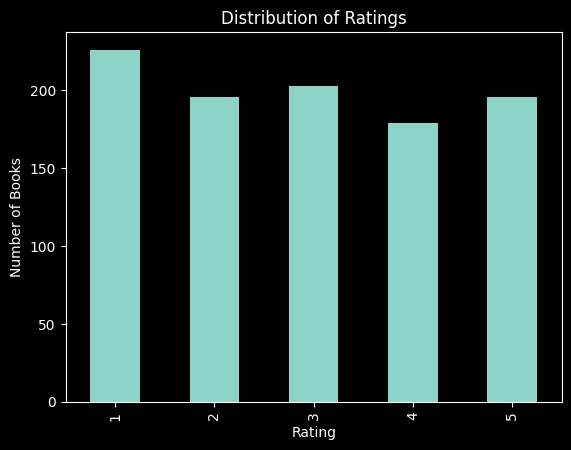

In [95]:
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

In [96]:
df_clean = df_clean.drop(columns=["tax_gbp", "num_reviews", "price_excl_tax_gbp", "price_incl_tax_gbp"])

This step provides an overview of the data distribution and helps identify potential anomalies or patterns.

In this step some several anomalies were identified. The columns `tax_gbp` and `num_reviews` contain only zero values, indicating a lack of variability and limited usefulness for analysis. This may be due to limitations in the data collection process.

Additionally, the columns `price_gbp`, `price_excl_tax_gbp`, and `price_incl_tax_gbp` contain identical values, suggesting redundancy in the dataset. As a result, the decision was made to delete columns with insufficient information.


## Question 1: Do higher-rated books tend to be more expensive?

This analysis investigates whether there is a relationship between book ratings and their prices. By grouping books based on their rating and calculating the average price for each group, it is possible to determine whether higher-rated books tend to be more expensive.

Additionally, a price categorization is introduced to simplify the analysis and enable comparison across price ranges.

To answer the first question, only the columns **title**, **category**, **price_gbp**, and **rating** are required. Therefore, a subset of the dataset, named `books_q1`, is created, and all subsequent analysis in this section is performed on this subset.

In [97]:
books_q1 = df_clean[["title", "category", "price_gbp", "rating"]].copy()
books_q1.head()

,title,category,price_gbp,rating
0,A Light in the Attic,Poetry,51.77,3
1,Tipping the Velvet,Historical Fiction,53.74,1
2,Soumission,Fiction,50.10,1
3,Sharp Objects,Mystery,47.82,4
4,Sapiens: A Brief History of Humankind,History,54.23,5


df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

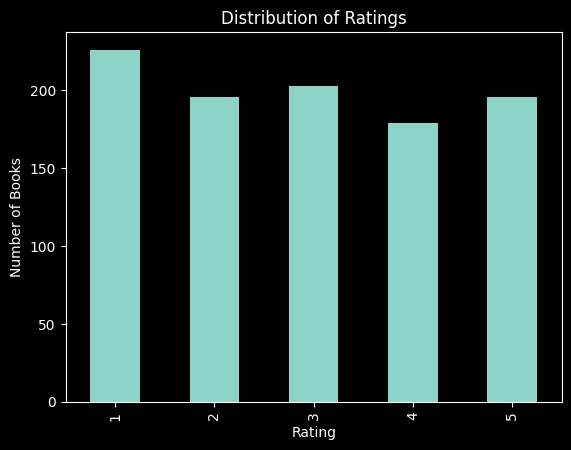

In [98]:
books_q1["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

The distribution of ratings is relatively balanced across all categories, with no rating level dominating the dataset. Although rating 1 appears slightly more frequent and rating 4 slightly less common, the differences are not substantial.

This indicates that the dataset contains a fairly even representation of books across all rating levels.

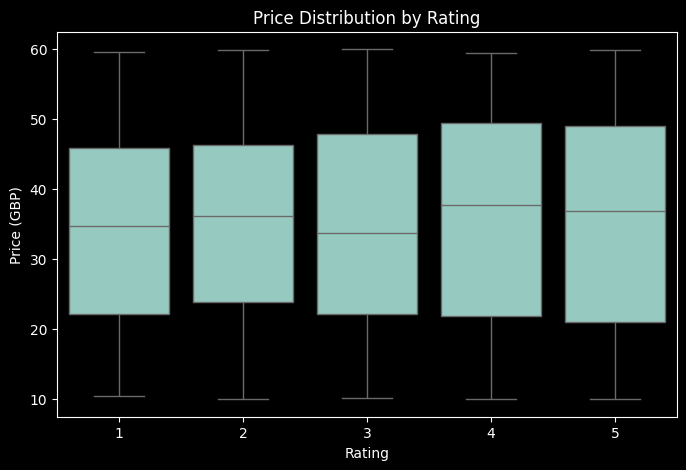

In [99]:
plt.figure(figsize=(8,5))
sns.boxplot(x="rating", y="price_gbp", data=df_clean)

plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price (GBP)")
plt.show()

The boxplot indicates that the distribution of book prices across rating levels is relatively similar.

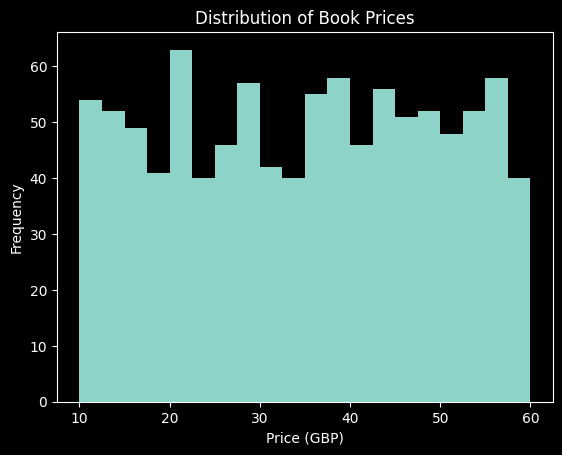

In [100]:
books_q1["price_gbp"].plot(kind="hist", bins=20)
plt.title("Distribution of Book Prices")
plt.xlabel("Price (GBP)")
plt.ylabel("Frequency")
plt.show()

The histogram suggests an approximately uniform distribution of book prices across the range of 10 to 60 GBP. There is no strong skewness or concentration of values in a specific interval. This indicates that prices are relatively evenly distributed, which supports dividing the data into balanced categories for further analysis.

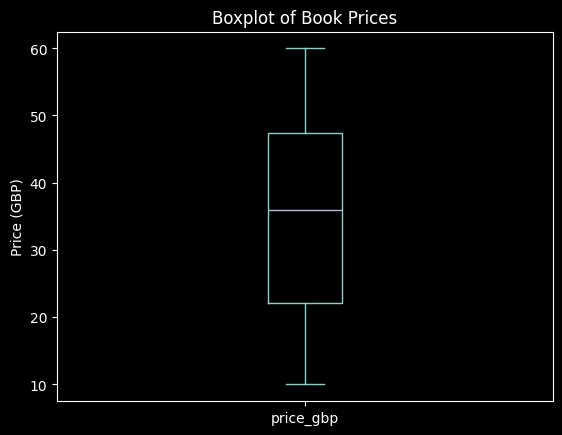

In [101]:
books_q1["price_gbp"].plot(kind="box")
plt.title("Boxplot of Book Prices")
plt.ylabel("Price (GBP)")
plt.show()

The boxplot shows that the median price is around 35 GBP, with most values falling between approximately 22 and 48 GBP. There are no significant outliers, and the distribution appears relatively balanced.

In [102]:
min_price = books_q1["price_gbp"].min()
max_price = books_q1["price_gbp"].max()
avg_price = books_q1["price_gbp"].mean()

print(f"Minimum price: {min_price:.2f}")
print(f"Maximum price: {max_price:.2f}")
print(f"Average price: {avg_price:.2f}")

Minimum price: 10.00
Maximum price: 59.99
Average price: 35.07


In [103]:
books_q1["price_category"] = pd.cut(
    books_q1["price_gbp"],
    bins=[0, 20, 40, 60],
    labels=["Cheap", "Medium", "Expensive"]
)

books_q1.head()

,title,category,price_gbp,rating,price_category
0,A Light in the Attic,Poetry,51.77,3,Expensive
1,Tipping the Velvet,Historical Fiction,53.74,1,Expensive
2,Soumission,Fiction,50.10,1,Expensive
3,Sharp Objects,Mystery,47.82,4,Expensive
4,Sapiens: A Brief History of Humankind,History,54.23,5,Expensive


Based on the observed distribution of prices, the price variable is divided into three categories: Cheap, Medium, and Expensive:

- **Cheap**: 0-20 gbp
- **Medium**: 20-40 gbp
- **Expensive**: 40-60 gbp

The bin boundaries were selected according to the data range and average price, allowing for a meaningful and balanced segmentation of the dataset.

In [104]:
books_q1["price_category"].value_counts()

price_category
Expensive    403
Medium       401
Cheap        196
Name: count, dtype: int64

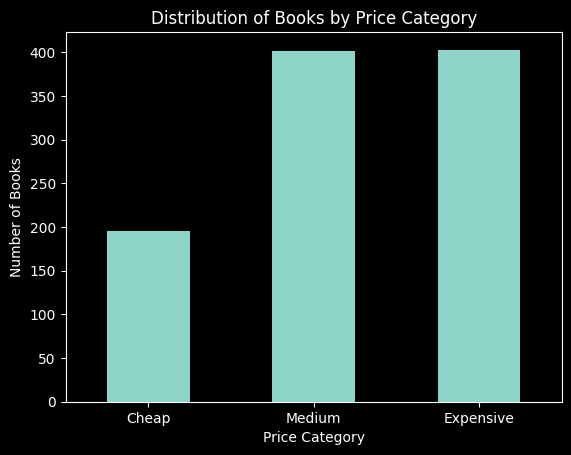

In [105]:
books_q1["price_category"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Books by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.show()

The distribution of books across price categories shows that the majority of books fall into the Medium and Expensive categories, with 401 and 403 books respectively. In contrast, the Cheap category contains significantly fewer books (196). This indicates that most books in the dataset are priced above 20 GBP, suggesting a concentration of prices in the medium-to-high range.

In [106]:
avg_price_by_rating = books_q1.groupby("rating")["price_gbp"].mean().sort_index()
avg_price_by_rating

rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price_gbp, dtype: float64

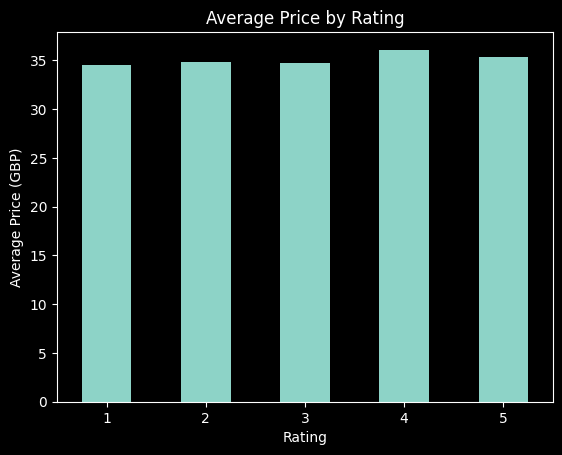

In [107]:
avg_price_by_rating.plot(kind="bar")
plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (GBP)")
plt.xticks(rotation=0)
plt.show()

The results show that the average price across rating levels is very similar. Although books with a rating of 4 have the highest average price, the differences between ratings are minimal.

The bar chart confirms that there is no clear increasing trend in price as the rating increases. The values remain relatively stable across all rating levels.

Therefore, it can be concluded that higher-rated books are not significantly more expensive than lower-rated ones, indicating that price is not a strong determinant of book rating.

**Answer to Question 1 "Do higher-rated books tend to be more expensive?"**

The analysis shows that higher-rated books do not tend to be more expensive. The average price remains relatively consistent across all rating levels, with only minor differences observed. Therefore, there is no strong relationship between book rating and price.